<a href="https://colab.research.google.com/github/MeetuKumari1/ml_productionization/blob/main/flight_price_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Project Name - Flight Price Prediction Model

Project Type - Productionization of ML Systems

Contribution - Individual

Name of Contributor - Meetu Kumari

GitHub Link -  https://github.com/MeetuKumari1/ml_productionization.git

Project Title:

Voyage Analytics: Integrating MLOps in Travel Productionization of ML Systems

## Business Context

In the realm of travel and tourism, the intersection of data analytics and machine learning presents an opportunity to revolutionize the way travel experiences are curated and delivered. This capstone project revolves around a trio of datasets - users, flights, and hotels - each providing a unique perspective on travel patterns and preferences. The goal is to leverage these datasets to build and deploy sophisticated machine learning models, serving a dual purpose: enhancing predictive capabilities in travel-related decision-making and mastering the art of MLOps through hands-on application.

### Brief overview of flight datasets

* travelCode: Identifier for the travel.

* userCode: User identifier(linked to the Users dataset)

* from: Origin of the flight.

* to: Destination of the flight.

* flightType: Type of flight (e.g., first class).

* price: Price of the flight.

* time: Flight duration.

* distance: Distance of the flight.

* agency: Flight agency.

* date: Date of the flight.

Project Objectives

Build a regression model to predict the price of a flight using the flights.csv dataset. Focus on feature selection, model training, and validation to ensure accuracy and reliability.

## Let's Begin !

### 1. Know Your Data

Import Libraries

In [1]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [3]:
# Dataset loading
from pathlib import Path
import zipfile

# zip_path = Path("C:/Users/Coditas-Admin/Documents/ml_productionization/travel_capstone.zip")
# extract_dir = zip_path.parent

# with zipfile.ZipFile(zip_path, "r") as zf:
#     zf.extractall(extract_dir)

# print(f"Extracted to: {extract_dir}")

# for google drive (colab)
from google.colab import drive
drive.mount('/content/drive')

zip_path = Path("/content/drive/MyDrive/AlmaBetter/AB_Specialisation_Track/capstone_project/ML_engineering/ml_productionization/travel_capstone.zip")
extract_dir = zip_path.parent
with zipfile.ZipFile(zip_path, "r") as zf:
    zf.extractall(extract_dir)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# load flight dataset
flights_df = pd.read_csv(
    "/content/drive/MyDrive/AlmaBetter/AB_Specialisation_Track/capstone_project/ML_engineering/ml_productionization/travel_capstone/flights.csv"
)

In [5]:
flights_df.head()

,travelCode,userCode,from,to,flightType,price,time,distance,agency,date
0,0,0,Recife (PE),Florianopolis (SC),firstClass,1434.38,1.76,676.53,FlyingDrops,09/26/2019
1,0,0,Florianopolis (SC),Recife (PE),firstClass,1292.29,1.76,676.53,FlyingDrops,09/30/2019
2,1,0,Brasilia (DF),Florianopolis (SC),firstClass,1487.52,1.66,637.56,CloudFy,10/03/2019
3,1,0,Florianopolis (SC),Brasilia (DF),firstClass,1127.36,1.66,637.56,CloudFy,10/04/2019
4,2,0,Aracaju (SE),Salvador (BH),firstClass,1684.05,2.16,830.86,CloudFy,10/10/2019


In [ ]:
flights_df.tail()

,travelCode,userCode,from,to,flightType,price,time,distance,agency,date
271883,135941,1339,Campo Grande (MS),Florianopolis (SC),firstClass,1446.34,1.49,573.81,CloudFy,07/12/2020
271884,135942,1339,Florianopolis (SC),Natal (RN),economic,726.95,1.84,709.37,CloudFy,07/16/2020
271885,135942,1339,Natal (RN),Florianopolis (SC),economic,873.07,1.84,709.37,CloudFy,07/20/2020
271886,135943,1339,Florianopolis (SC),Rio de Janeiro (RJ),economic,313.62,1.21,466.30,CloudFy,07/23/2020
271887,135943,1339,Rio de Janeiro (RJ),Florianopolis (SC),economic,533.69,1.21,466.30,CloudFy,07/26/2020


In [ ]:
# Dataset Rows & Columns count
print(f"Total number of rows: {flights_df.shape[0]}")
print(f"Total number of columns: {flights_df.shape[1]}")

Total number of rows: 271888
Total number of columns: 10


#### Dataset Information

In [ ]:
#Dataset Info
flights_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271888 entries, 0 to 271887
Data columns (total 10 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   travelCode  271888 non-null  int64  
 1   userCode    271888 non-null  int64  
 2   from        271888 non-null  object 
 3   to          271888 non-null  object 
 4   flightType  271888 non-null  object 
 5   price       271888 non-null  float64
 6   time        271888 non-null  float64
 7   distance    271888 non-null  float64
 8   agency      271888 non-null  object 
 9   date        271888 non-null  object 
dtypes: float64(3), int64(2), object(5)
memory usage: 20.7+ MB


In [ ]:
#dataset duplicate values
flights_df.duplicated().value_counts()

False    271888
Name: count, dtype: int64

In [ ]:
#missing values or null values
flights_df.isnull().sum()

travelCode    0
userCode      0
from          0
to            0
flightType    0
price         0
time          0
distance      0
agency        0
date          0
dtype: int64

#### What did you know about your dataset?

This dataset has 271,888 rows and 10 columns. It contains no missing values and no duplicate rows. The feature mix includes 2 integer identifiers (`travelCode`, `userCode`), 3 numeric float columns (`price`, `time`, `distance`), and 5 categorical columns (`from`, `to`, `flightType`, `agency`, `date`). The in-memory size is ~20.7 MB. For the regression task, `price` is the target variable and the remaining fields can be used as features after encoding and date parsing.

### 2. Understanding the Variables

##### Check Unique Values for each variable.

In [ ]:
#dataset description
flights_df.describe()

,travelCode,userCode,price,time,distance
count,271888.000000,271888.000000,271888.00000,271888.000000,271888.000000
mean,67971.500000,667.505495,957.37503,1.421147,546.955535
std,39243.724665,389.523127,362.31189,0.542541,208.851288
min,0.000000,0.000000,301.51000,0.440000,168.220000
25%,33985.750000,326.000000,672.66000,1.040000,401.660000
50%,67971.500000,659.000000,904.00000,1.460000,562.140000
75%,101957.250000,1011.000000,1222.24000,1.760000,676.530000
max,135943.000000,1339.000000,1754.17000,2.440000,937.770000


In [ ]:
# description for only categorical columns
flights_df.describe(include=['object'])

,from,to,flightType,agency,date
count,271888,271888,271888,271888,271888
unique,9,9,3,3,999
top,Florianopolis (SC),Florianopolis (SC),firstClass,Rainbow,09/26/2019
freq,57317,57317,116418,116752,1335


In [ ]:
# Check Unique Values for each variable.
flights_df.nunique()

travelCode    135944
userCode        1335
from               9
to                 9
flightType         3
price            490
time              33
distance          35
agency             3
date             999
dtype: int64

In [ ]:
## Unique Values for ['from','to','flightType', 'time', 'distance', 'agency'] variable
col_list = ['from','to','flightType', 'time', 'distance', 'agency']
for col in col_list:
    print(f"Unique values for column_name '{col}' is: \n{flights_df[col].unique()}\n")

Unique values for column_name 'from' is: 
['Recife (PE)' 'Florianopolis (SC)' 'Brasilia (DF)' 'Aracaju (SE)'
 'Salvador (BH)' 'Campo Grande (MS)' 'Sao Paulo (SP)' 'Natal (RN)'
 'Rio de Janeiro (RJ)']

Unique values for column_name 'to' is: 
['Florianopolis (SC)' 'Recife (PE)' 'Brasilia (DF)' 'Salvador (BH)'
 'Aracaju (SE)' 'Campo Grande (MS)' 'Sao Paulo (SP)' 'Natal (RN)'
 'Rio de Janeiro (RJ)']

Unique values for column_name 'flightType' is: 
['firstClass' 'economic' 'premium']

Unique values for column_name 'time' is: 
[1.76 1.66 2.16 1.69 1.11 1.26 0.72 0.67 0.58 1.43 2.05 1.39 0.63 1.02
 0.46 1.44 1.55 2.1  0.48 2.3  1.49 1.36 0.44 0.65 2.09 1.04 0.85 0.86
 1.46 1.85 1.84 1.21 2.44]

Unique values for column_name 'distance' is: 
[676.53 637.56 830.86 650.1  425.98 486.52 277.7  257.81 676.56 222.67
 550.69 788.55 535.4  242.21 392.76 176.33 555.74 597.61 808.85 183.37
 885.57 573.81 522.34 168.22 250.68 806.48 595.03 401.66 327.55 331.89
 562.14 710.57 709.37 466.3  937.77]

Unique

In [ ]:
# checknig start and end date
print("start date in flight's dataset is:---> ",flights_df['date'].min())
print("end date in flight's dataset is:---> ",flights_df['date'].max())

start date in flight's dataset is:--->  01/01/2021
end date in flight's dataset is:--->  12/31/2022


#### 3. Data wrangling

In [ ]:
# Write your code to make your dataset analysis ready.
# created new variables from date columns
flights_df['date'] = pd.to_datetime(flights_df['date'], format="%m/%d/%Y")
flights_df['year'] = flights_df['date'].dt.year
flights_df['month'] = flights_df['date'].dt.month
flights_df['day'] = flights_df['date'].dt.day
flights_df['year_index'] = flights_df['year'] - flights_df['date'].min().year


In [ ]:
# ensure correct dtypes
for col in ['price', 'time', 'distance']:
    flights_df[col] = pd.to_numeric(flights_df[col], errors='coerce')

# normalize text fields
for col in ['from', 'to', 'flightType', 'agency']:
    flights_df[col] = flights_df[col].astype(str).str.strip()

# handle missing values introduced by coercion
flights_df = flights_df.dropna(subset=['price', 'time', 'distance', 'from', 'to', 'flightType', 'agency', 'date'])

# remove duplicate rows if any
flights_df = flights_df.drop_duplicates()


#### What all manipulations have you done and insights you found?

- Converted `price`, `time`, and `distance` to numeric types (invalid values coerced).
- Trimmed whitespace in categorical text columns: `from`, `to`, `flightType`, `agency`.
- Dropped rows with missing values in critical columns.
- Removed duplicate rows.
- Extracted `year`, `month`, and `day` from the `date` column for time-based analysis.
- Calculated `year_index` by subtracting the minimum year, creating a 0-based year trend index.

#### 4. Focused EDA for Flight Price Prediction using flights_df.

Explore Feature Distributions and Correlations in flights_df


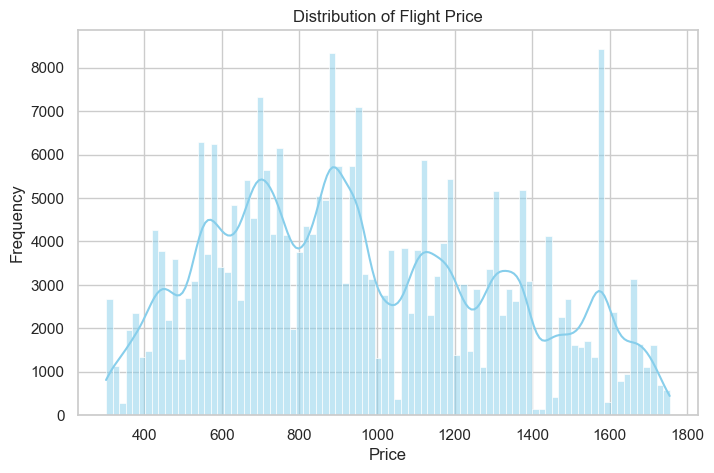

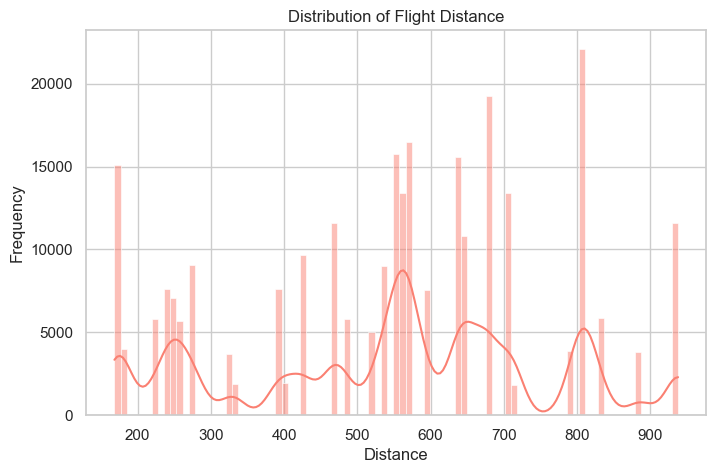

In [ ]:
# Set plot style
sns.set_theme(style="whitegrid")
# Plot distribution of flight price
plt.figure(figsize=(8, 5))
sns.histplot(flights_df['price'], kde=True, color='skyblue')
plt.title("Distribution of Flight Price")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

# Plot distribution of flight distance
plt.figure(figsize=(8, 5))
sns.histplot(flights_df['distance'], kde=True, color='salmon')
plt.title("Distribution of Flight Distance")
plt.xlabel("Distance")
plt.ylabel("Frequency")
plt.show()


The price distribution is right‑skewed: most flights are clustered at lower prices, with a long tail of expensive outliers. This skew can make models sensitive to outliers, so a log transform (or robust loss/metrics) may help stabilize training.

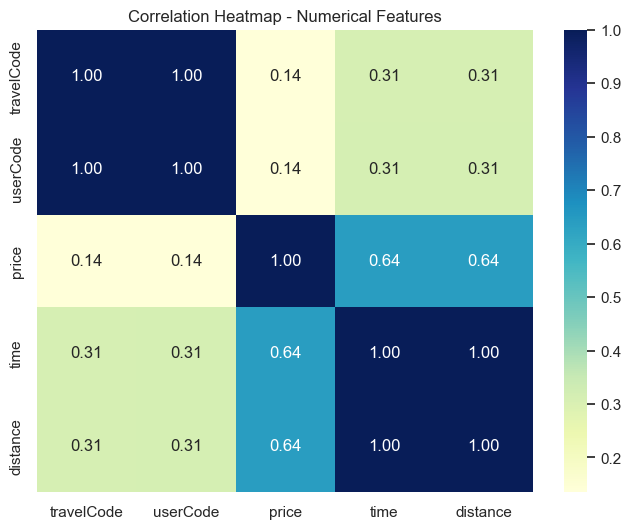

In [ ]:
# Check Correlation Between Numerical Features and price
# Which numerical features are correlated with flight price?
# Selecting only numerical columns
numeric_cols = flights_df.select_dtypes(include=['int64', 'float64'])

# Correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='YlGnBu', fmt='.2f')
plt.title("Correlation Heatmap - Numerical Features")
plt.show()

price shows a moderate positive correlation with time (~0.64), indicating longer durations are generally associated with higher prices.
price also correlates with distance (~0.64), which aligns with longer trips tending to cost more.
travelCode and userCode have near‑zero correlation and are identifiers; they should be excluded from modeling (or only used as categorical IDs if there’s a justified encoding strategy).

#### 5. Feature Manipulation & Selection

In [ ]:
# Categorical encoding is handled in the modeling pipeline
from sklearn.preprocessing import OneHotEncoder

##### What all categorical encoding techniques have you used & why did you use those techniques?

One-hot encoding is applied inside the modeling pipeline. This preserves the categorical nature of the variables and avoids the ordinality assumption present in label encoding. By fitting the encoder only on the training data, we also avoid data leakage during evaluation.

In [ ]:
# Select features wisely to avoid overfitting
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

# Separate features and target variable (drop identifiers + date parts)
X = flights_df.drop(
    ['travelCode', 'userCode', 'date', 'year', 'month', 'day', 'year_index', 'price'],
    axis=1,
)
y = flights_df['price']

cat_cols = ['from', 'to', 'flightType', 'agency']
num_cols = ['time', 'distance']

preprocess = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
    ]
)

rf_model = RandomForestRegressor(random_state=42)
rf_pipeline = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', rf_model),
])

rf_pipeline.fit(X, y)

feature_names = rf_pipeline.named_steps['preprocess'].get_feature_names_out()
feature_importances = rf_pipeline.named_steps['model'].feature_importances_

In [ ]:
# Extract feature importances and corresponding feature names
feature_importances_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})
feature_importances_df = feature_importances_df.sort_values(by='Importance', ascending=False)

# Display top 10 important features
top_10_features = feature_importances_df.head(10)
print(top_10_features)

                         Feature  Importance
21    cat__flightType_firstClass    0.296787
1                  num__distance    0.246826
0                      num__time    0.228616
22       cat__flightType_premium    0.065414
5   cat__from_Florianopolis (SC)    0.050607
11          cat__to_Aracaju (SE)    0.021427
14    cat__to_Florianopolis (SC)    0.012494
10      cat__from_Sao Paulo (SP)    0.012392
20      cat__flightType_economic    0.011478
3        cat__from_Brasilia (DF)    0.009388


We can analyze the feature importances obtained from the random forest model to identify the most important features. Features with higher importances contribute more to the prediction of flight prices. These important features are valuable for understanding the factors influencing flight prices and can guide strategic decision-making in pricing, marketing, and route planning.

#### Data Splitting

In [ ]:
# Split your data to train and test. Choose Splitting ratio wisely.
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

We chose a test size of 20% to ensure that there is enough data for testing the model's performance while still allowing a larger portion for training. A random state is specified for reproducibility, ensuring that the split remains consistent across different runs.

This splitting ratio helps in assessing the generalization performance of the model on unseen data and provides a reliable estimate of its performance in real-world scenarios.

#### 6. Training Regression Model

 I’ll proceed with some important Regressor Model and check there accuracy and based on there performance will select the best fitted regression model

In [ ]:
# Install xgboost if not already installed
#%pip install -q xgboost

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

In [ ]:
cat_cols = ['from', 'to', 'flightType', 'agency']
num_cols = ['time', 'distance']

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ]
)

In [ ]:
def eval_regression(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return {"MAE": mae, "RMSE": rmse, "R2": r2}

In [ ]:
models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.01),
    "RandomForest": RandomForestRegressor(
        n_estimators=300, max_depth=None, random_state=42, n_jobs=-1
    ),
    "GradientBoosting": GradientBoostingRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=3, random_state=42
    ),
}

In [ ]:
results = []

for name, model in models.items():
    pipe = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", model),
    ])

    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)

    metrics = eval_regression(y_test, preds)
    metrics["Model"] = name
    results.append(metrics)

results_df = pd.DataFrame(results).set_index("Model").sort_values("RMSE")
results_df

,MAE,RMSE,R2
Model,,,
RandomForest,4.927867e-12,6.726674e-12,1.000000
GradientBoosting,2.789341e+01,3.500888e+01,0.990699
LinearRegression,8.132140e+01,1.031519e+02,0.919250
Ridge,8.127574e+01,1.031793e+02,0.919207
Lasso,8.126911e+01,1.031926e+02,0.919187


 #### Cross‑validation (robust model comparison)

In [ ]:
from sklearn.model_selection import KFold, cross_validate

cv = KFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2"
}

cv_results = {}

for name, model in models.items():
    pipe = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", model),
    ])
    scores = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring)
    cv_results[name] = {
        "MAE": -scores["test_MAE"].mean(),
        "RMSE": -scores["test_RMSE"].mean(),
        "R2": scores["test_R2"].mean()
    }

cv_results_df = pd.DataFrame(cv_results).T.sort_values("RMSE")
cv_results_df

,MAE,RMSE,R2
RandomForest,4.660025e-12,6.081258e-12,1.000000
GradientBoosting,2.770874e+01,3.447788e+01,0.990934
LinearRegression,8.106532e+01,1.028304e+02,0.919366
Ridge,8.102292e+01,1.028664e+02,0.919310
Lasso,8.101734e+01,1.028813e+02,0.919286


##### Final hold‑out test evaluation

In [ ]:
final_results = []

for name, model in models.items():
    pipe = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", model),
    ])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    metrics = eval_regression(y_test, preds)
    metrics["Model"] = name
    final_results.append(metrics)

final_results_df = pd.DataFrame(final_results).set_index("Model").sort_values("RMSE")
final_results_df

,MAE,RMSE,R2
Model,,,
RandomForest,4.926197e-12,6.726323e-12,1.000000
GradientBoosting,2.789341e+01,3.500888e+01,0.990699
LinearRegression,8.132140e+01,1.031519e+02,0.919250
Ridge,8.127574e+01,1.031793e+02,0.919207
Lasso,8.126911e+01,1.031926e+02,0.919187


In [ ]:
# Select best model (lowest RMSE) for deployment
leaderboard = cv_results_df if 'cv_results_df' in globals() else (
    final_results_df if 'final_results_df' in globals() else results_df
)

best_model_name = leaderboard['RMSE'].idxmin()
best_model = models[best_model_name]

best_pipeline = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", best_model),
])

# Fit on full data for deployment if available, else fit on train split
if 'X' in globals() and 'y' in globals():
    best_pipeline.fit(X, y)
else:
    best_pipeline.fit(X_train, y_train)

print(f"Best model selected for deployment: {best_model_name}")

Best model selected for deployment: RandomForest
